In [11]:
from torch.utils.data import DataLoader
from miao import VolumeDataset, load_config

In [12]:
config = load_config("/groups/troidl/home/troidlj/miaio/examples/config.yaml")
dataset = VolumeDataset(config)

VolumeDataset: 2 volume(s), 1000 samples/epoch, patch_size=[128, 128, 32]
  [Jiefu Cerebellum FIB-SEM]
    image: axes='zyx', shape=[13745, 7627, 6274], dtype=uint8
    scale 0: voxel_size=[16.0, 16.0, 16.0] nanometer
    scale 1: voxel_size=[32.0, 32.0, 32.0] nanometer
    scale 2: voxel_size=[64.0, 64.0, 64.0] nanometer
    label: axes='zyx', shape=[13745, 7627, 6274], dtype=uint32
    sampling: weight=0.50, center_range=[[1197, 1457, 1132], [5561, 4773, 6020]]
    normalize: uint8 -> [0, 1]
  [H01 Human Cortex]
    image: axes='xyz', shape=[16384, 16384, 1024], dtype=uint8
    scale 0: voxel_size=[4.0, 4.0, 33.0] nanometer
    scale 1: voxel_size=[8.0, 8.0, 33.0] nanometer
    scale 2: voxel_size=[16.0, 16.0, 33.0] nanometer
    label: axes='xyz', shape=[8192, 8192, 1024], dtype=uint64
    sampling: weight=0.50, center_range=[[512, 512, 16], [15872, 15872, 1008]]
    normalize: uint8 -> [0, 1]
  output: axes='lcxyz', tensor_shape=(L, C, X, Y, Z)


In [13]:
x = dataset[0]

print(x['meta'])
print(x['img'].shape)
print(x['bbox'].shape)

{'volume': 'H01 Human Cortex', 'coordinate': [3589, 7849, 203], 'scale_levels': [0, 1, 2]}
torch.Size([3, 1, 128, 128, 32])
torch.Size([3, 2, 3])


In [14]:
loader = DataLoader(dataset, batch_size=4, shuffle=True)

batch = next(iter(loader))

tensor([[-256., -256., -528.],
        [ 256.,  256.,  528.]])
tensor([[-512., -512., -528.],
        [ 512.,  512.,  528.]])
tensor([[-1032., -1024.,  -528.],
        [ 1016.,  1024.,   528.]])


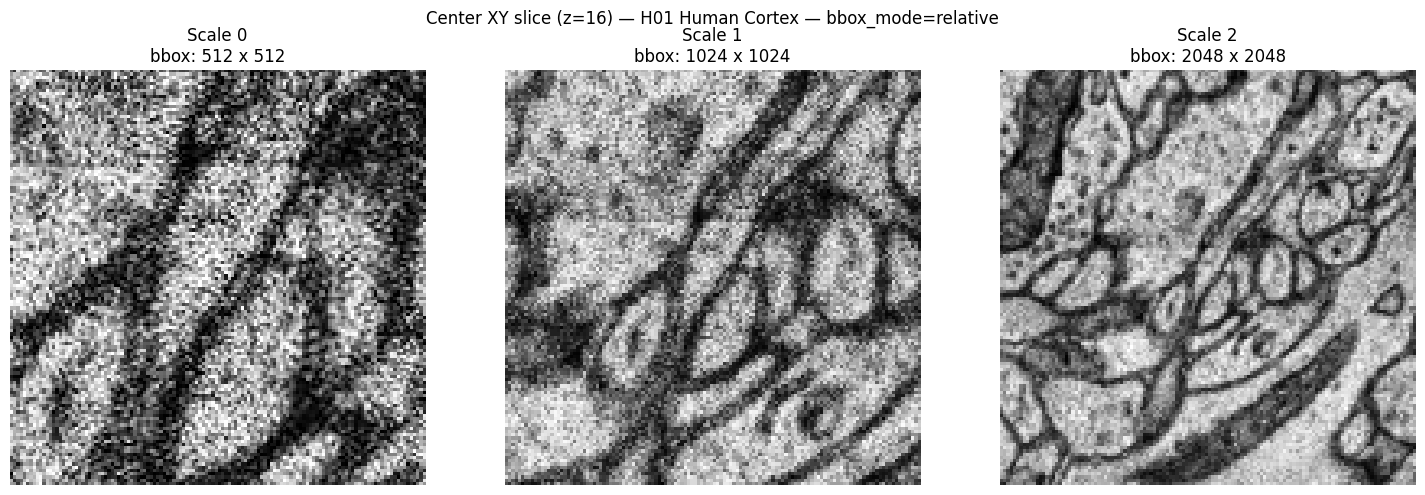

In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

sample = dataset[0]
img = sample["img"]    # (L, C, X, Y, Z) for output_axes="lcxyz"
bbox = sample["bbox"]  # (L, 2, Nd_spatial)
num_levels = img.shape[0]
center_z = img.shape[4] // 2

fig, axes = plt.subplots(1, num_levels, figsize=(5 * num_levels, 5))
if num_levels == 1:
    axes = [axes]
for i in range(num_levels):
    axes[i].imshow(img[i, 0, :, :, center_z].numpy().T, cmap="gray", origin="lower")

    print(bbox[i])

    # Annotate with bbox extent
    bb_min = bbox[i, 0].tolist()
    bb_max = bbox[i, 1].tolist()
    extent_x = bb_max[0] - bb_min[0]
    extent_y = bb_max[1] - bb_min[1]
    scale = sample["meta"]["scale_levels"][i]
    axes[i].set_title(f"Scale {scale}\nbbox: {extent_x:.0f} x {extent_y:.0f}")
    axes[i].axis("off")

mode = config.bbox_mode
plt.suptitle(f"Center XY slice (z={center_z}) — {sample['meta']['volume']} — bbox_mode={mode}")
plt.tight_layout()
plt.show()